                                        Decision Delay Cost Analyzer   

📌 Business Objective

In many organizations, data is available on time, but decisions are delayed.
These delays silently reduce profit, efficiency, and revenue opportunities.

Goal:
Quantify how decision delays impact profit and identify high-risk products and regions.

In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as plt
import matplotlib.pyplot as plt


In [36]:
df=pd.read_excel("C:/Users/surek/OneDrive/Desktop/Decision_Delay_Cost_Analyzer.xlsx")

df

In [37]:
df.head()

,Order_ID,Product,Category,Region,Event_Date,Decision_Date,Sales,Profit,Stock_Level
0,ORD0001,Laptop,Office Supplies,West,2023-05-26,2023-05-30,4266,-7642,47
1,ORD0002,Monitor,Technology,West,2023-01-15,2023-01-16,10560,-1236,198
2,ORD0003,Laptop,Technology,West,2023-05-21,2023-06-04,6008,-3568,160
3,ORD0004,Printer,Furniture,South,2023-01-06,2023-01-19,4033,-7377,76
4,ORD0005,Monitor,Office Supplies,East,2023-05-20,2023-05-20,9277,7673,62


🔍 Data Overview

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       300 non-null    object        
 1   Product        300 non-null    object        
 2   Category       300 non-null    object        
 3   Region         300 non-null    object        
 4   Event_Date     300 non-null    datetime64[ns]
 5   Decision_Date  300 non-null    datetime64[ns]
 6   Sales          300 non-null    int64         
 7   Profit         300 non-null    int64         
 8   Stock_Level    300 non-null    int64         
dtypes: datetime64[ns](2), int64(3), object(4)
memory usage: 21.2+ KB


In [39]:
df['Event_Date'] = pd.to_datetime(df['Event_Date'])
df['Decision_Date'] = pd. to_datetime(df['Decision_Date'])

⏱ Decision Delay Calculation (Core KPI)

Decision Delay measures how late a business decision was taken after the event.

In [40]:
df['Decision_Delay_Days'] = (
    df['Decision_Date'] - df['Event_Date']
).dt.days


In [41]:
df[['Order_ID', 'Decision_Delay_Days']].head()


,Order_ID,Decision_Delay_Days
0,ORD0001,4
1,ORD0002,1
2,ORD0003,14
3,ORD0004,13
4,ORD0005,0


📉 Impact of Decision Delay on Profit
Average Profit by Delay Duration

In [42]:
delay_profit = (
    df.groupby('Decision_Delay_Days')['Profit']
      .mean()
      .reset_index()
)
delay_profit


,Decision_Delay_Days,Profit
0,0,128.071429
1,1,362.888889
2,2,253.000000
3,3,-303.809524
4,4,-186.347826
5,5,2255.200000
6,6,1128.772727
7,7,-823.375000
8,8,-1069.904762
9,9,-2372.411765


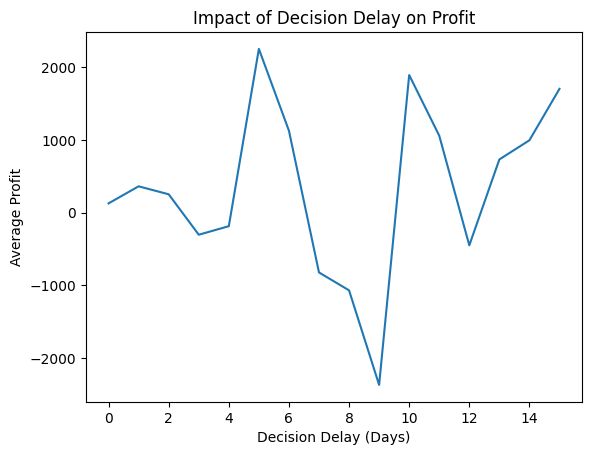

In [45]:
plt.figure()
plt.plot(delay_profit['Decision_Delay_Days'], delay_profit['Profit'])
plt.xlabel("Decision Delay (Days)")
plt.ylabel("Average Profit")
plt.title("Impact of Decision Delay on Profit")
plt.show()


🧮 Decision Delay Bucketing

To make insights executive-friendly, delays are grouped into buckets.

In [47]:
df['Delay_Bucket'] = pd.cut(
    df['Decision_Delay_Days'],
    bins=[-1, 2, 5, 10, 30],
    labels=['Fast', 'Medium', 'Slow', 'Critical']
)


In [48]:
df['Delay_Bucket'].value_counts()


Delay_Bucket
Slow        102
Critical     83
Medium       64
Fast         51
Name: count, dtype: int64

💰 Profit Impact by Delay Category

In [51]:
bucket_profit = (
    df.groupby('Delay_Bucket', observed=True)['Profit']
      .sum()
      .reset_index()
)



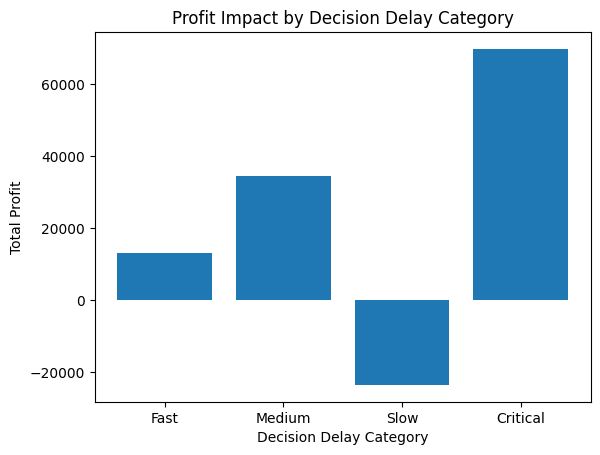

In [52]:
plt.figure()
plt.bar(bucket_profit['Delay_Bucket'], bucket_profit['Profit'])
plt.xlabel("Decision Delay Category")
plt.ylabel("Total Profit")
plt.title("Profit Impact by Decision Delay Category")
plt.show()


📦 High-Risk Product Analysis

In [53]:
product_risk = df.groupby('Product').agg(
    Avg_Delay=('Decision_Delay_Days', 'mean'),
    Total_Profit=('Profit', 'sum')
).reset_index()

product_risk.sort_values('Avg_Delay', ascending=False)


,Product,Avg_Delay,Total_Profit
1,Desk,7.754717,18884
4,Printer,7.687500,-25155
5,Router,7.297872,51195
2,Laptop,7.177419,-21460
0,Chair,7.140000,1171
3,Monitor,6.700000,69104


🌍 Region-Wise Decision Risk

In [55]:
region_analysis = df.groupby('Region').agg(
    Avg_Delay=('Decision_Delay_Days', 'mean'),
    Total_Profit=('Profit', 'sum')
).reset_index()

region_analysis


,Region,Avg_Delay,Total_Profit
0,Central,7.042254,90119
1,East,6.986842,53969
2,South,7.300000,-30148
3,West,7.784946,-20201


🚨 Action Recommendation Engine

Automatically flag risky orders based on delay severity.

In [56]:
df['Action_Required'] = df['Delay_Bucket'].apply(
    lambda x: 'Immediate Action' if x in ['Slow', 'Critical'] else 'Monitor'
)


In [57]:
df[['Order_ID', 'Delay_Bucket', 'Action_Required']].head()


,Order_ID,Delay_Bucket,Action_Required
0,ORD0001,Medium,Monitor
1,ORD0002,Fast,Monitor
2,ORD0003,Critical,Immediate Action
3,ORD0004,Critical,Immediate Action
4,ORD0005,Fast,Monitor


Executive Summary
Key Findings

Profit declines sharply after decision delays exceed 5 days

Critical delays cause significant cumulative losses

Certain products and regions are repeatedly affected

Business Recommendations

Enforce decision SLAs within 3 days

Introduce alerts for critical delays

Prioritize fast decisions for high-margin products

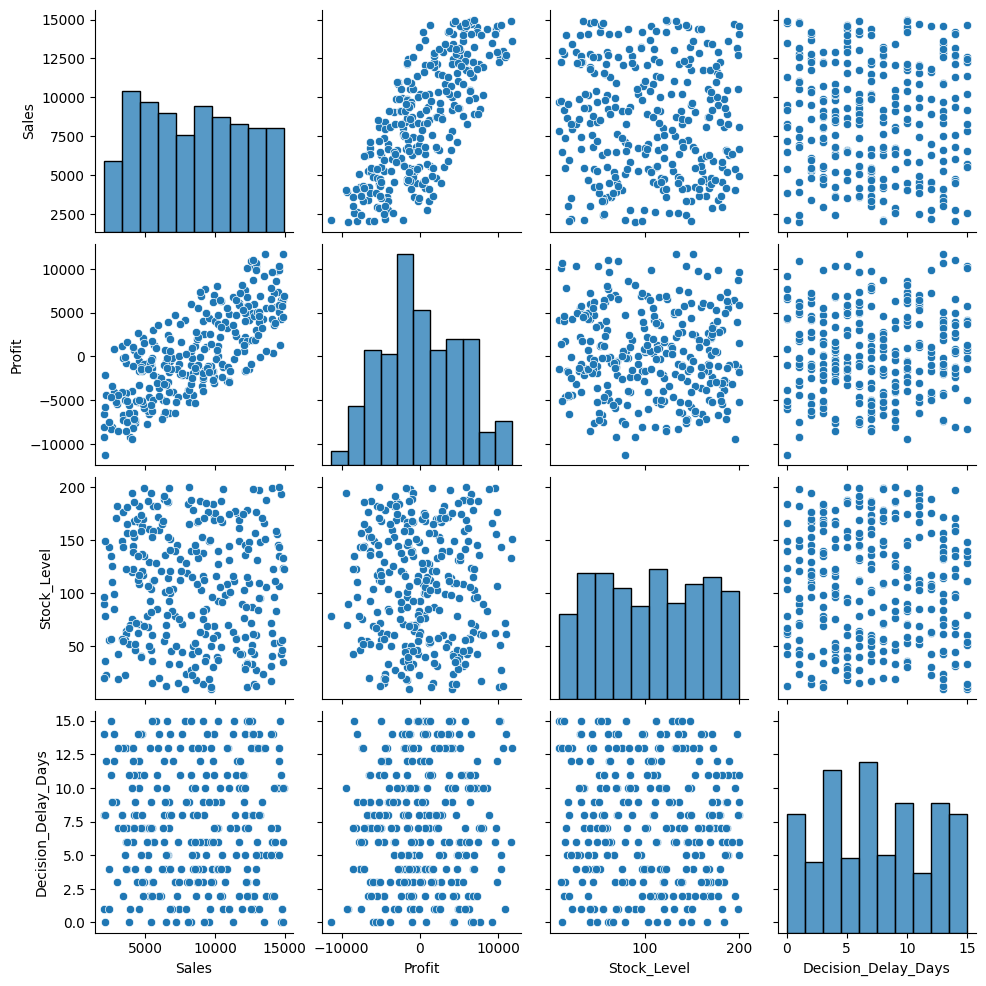

In [58]:
sns.pairplot(df)